In [ ]:
import pandas as pd # data manipulation tool
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import joblib
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns           # For advanced visualizations
sns.set(style="whitegrid")      # Set style for seaborn

# Load Dataset

In [42]:
df1 = pd.read_csv("2.csv")

# Drop irrelevant columns

In [44]:
# Create cleaned dataframe in one step (more memory efficient)
df = df1.drop(
    columns=["id", "first_name", "last_name", "email",
            "part_time_job", "absence_days", "weekly_self_study_hours"]
).query("career_aspiration != 'Unknown'").copy()

# Verify
print(f"Original shape: {df1.shape}")
print(f"Cleaned shape: {df.shape}")
print("\nCareer Distribution:\n", df["career_aspiration"].value_counts())

# Optional: Reset index if needed
df = df.reset_index(drop=True)

Original shape: (6000, 17)
Cleaned shape: (5331, 10)

Career Distribution:
 career_aspiration
Software Engineer        945
Business Owner           927
Banker                   507
Lawyer                   414
Accountant               378
Doctor                   357
Real Estate Developer    249
Stock Investor           219
Construction Engineer    204
Artist                   201
Game Developer           189
Government Officer       183
Teacher                  177
Designer                 168
Scientist                117
Writer                    96
Name: count, dtype: int64


# Encode binary categorical features

In [45]:
df["gender"] = df["gender"].map({"male": 0, "female": 1})
df["extracurricular_activities"] = df["extracurricular_activities"].astype(int)

In [46]:
# making a copy of career_aspiration
career_asp_cp = df["career_aspiration"]

In [47]:
print("\nClass Distribution:\n", df["career_aspiration"].value_counts())


Class Distribution:
 career_aspiration
Software Engineer        945
Business Owner           927
Banker                   507
Lawyer                   414
Accountant               378
Doctor                   357
Real Estate Developer    249
Stock Investor           219
Construction Engineer    204
Artist                   201
Game Developer           189
Government Officer       183
Teacher                  177
Designer                 168
Scientist                117
Writer                    96
Name: count, dtype: int64


Dataset has a highly imbalanced class distribution for career_aspiration, with some classes (e.g., Software Engineer with 945 samples) having 10x more samples than others (e.g., Writer with only 96 samples). This imbalance can severely bias our model toward majority classes

# Encode target variable ("career_aspiration")

In [48]:
le_aspiration = LabelEncoder()
df["career_aspiration"] = le_aspiration.fit_transform(df["career_aspiration"])

In [49]:
df["career_aspiration"].value_counts()

,count
career_aspiration,
12,945
3,927
2,507
9,414
0,378
6,357
10,249
13,219
4,204


# Summary of the DataFrame

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5331 entries, 0 to 5330
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   gender                      5331 non-null   int64
 1   extracurricular_activities  5331 non-null   int64
 2   career_aspiration           5331 non-null   int64
 3   math_score                  5331 non-null   int64
 4   history_score               5331 non-null   int64
 5   physics_score               5331 non-null   int64
 6   chemistry_score             5331 non-null   int64
 7   biology_score               5331 non-null   int64
 8   english_score               5331 non-null   int64
 9   geography_score             5331 non-null   int64
dtypes: int64(10)
memory usage: 416.6 KB


In [51]:
print(df.isnull().sum())

gender                        0
extracurricular_activities    0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64


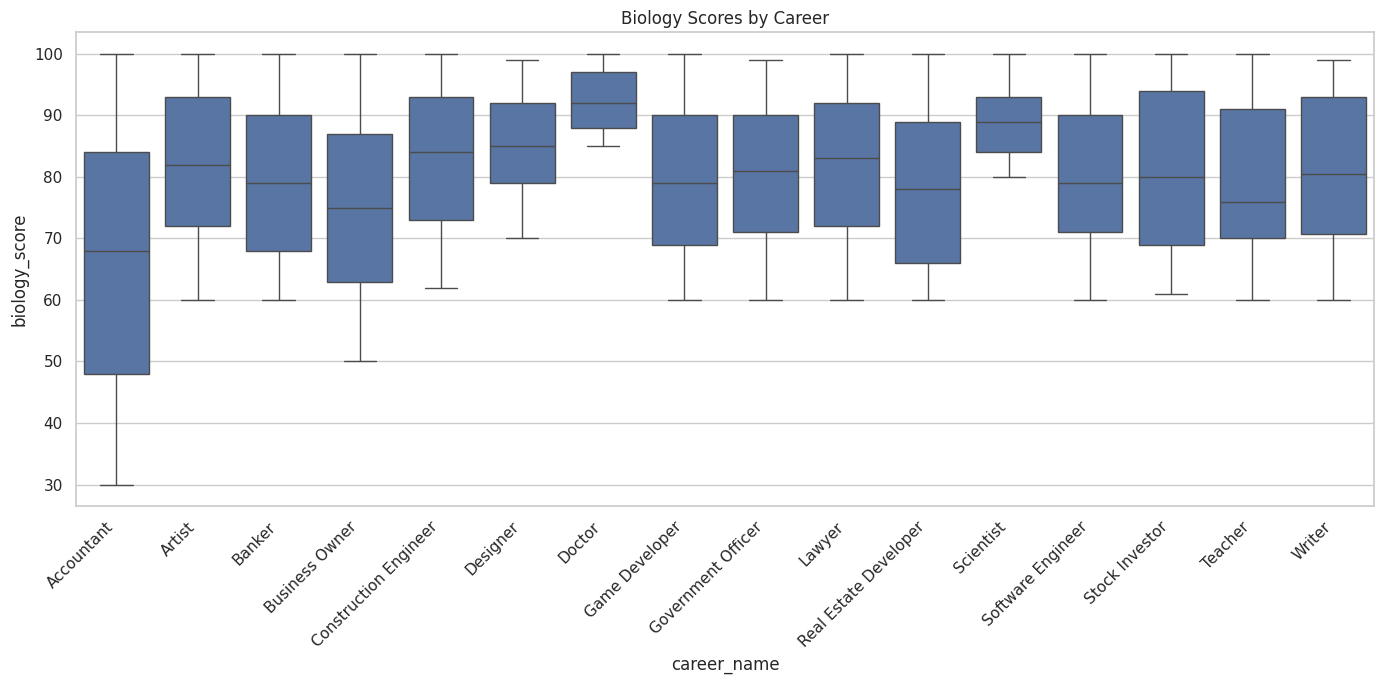

In [54]:
df['career_name'] = le_aspiration.inverse_transform(df['career_aspiration'])

plt.figure(figsize=(14, 7))
sns.boxplot(
    x='career_name',
    y='biology_score',
    data=df,
    order=sorted(df['career_name'].unique())
)
plt.title("Biology Scores by Career")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

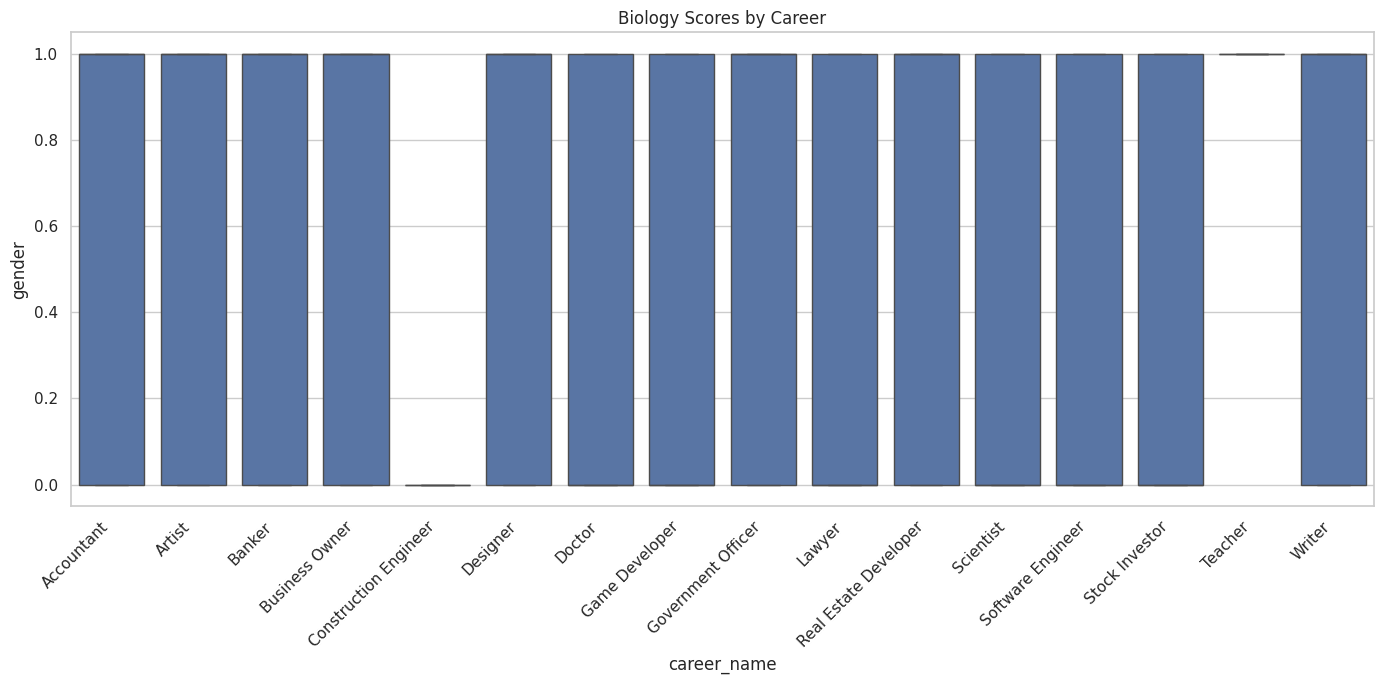

In [55]:
df['career_name'] = le_aspiration.inverse_transform(df['career_aspiration'])

plt.figure(figsize=(14, 7))
sns.boxplot(
    x='career_name',
    y='gender',
    data=df,
    order=sorted(df['career_name'].unique())
)
plt.title("Biology Scores by Career")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

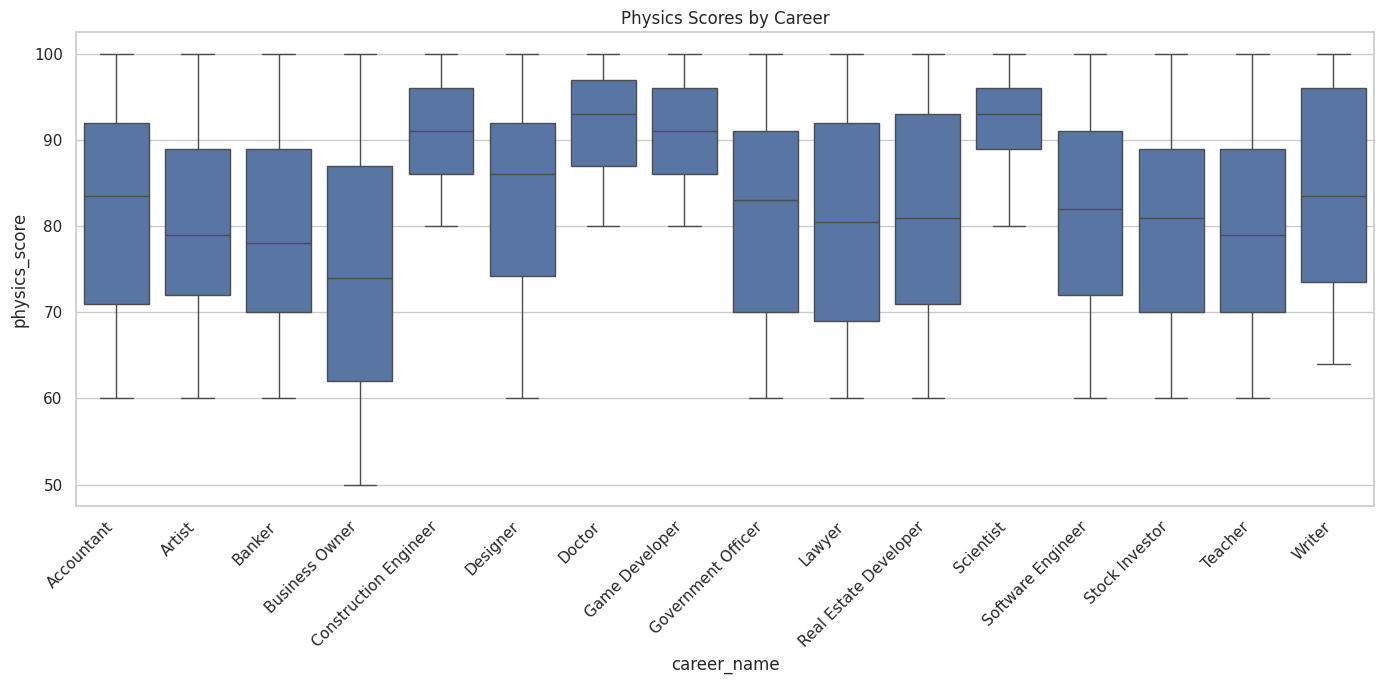

In [56]:
df['career_name'] = le_aspiration.inverse_transform(df['career_aspiration'])

plt.figure(figsize=(14, 7))
sns.boxplot(
    x='career_name',
    y='physics_score',
    data=df,
    order=sorted(df['career_name'].unique())
)
plt.title("Physics Scores by Career")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

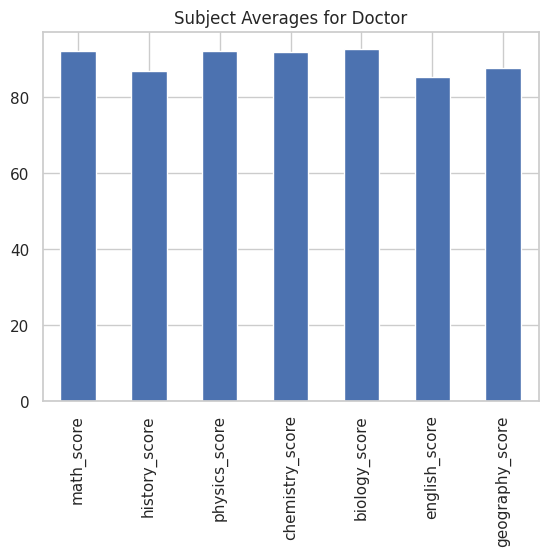

In [57]:
career_name = "Doctor"
career_code = le_aspiration.transform([career_name])[0]
career_data = df[df['career_aspiration'] == career_code]
career_data[numeric_cols].mean().plot(kind='bar', title=f"Subject Averages for {career_name}")
plt.show()

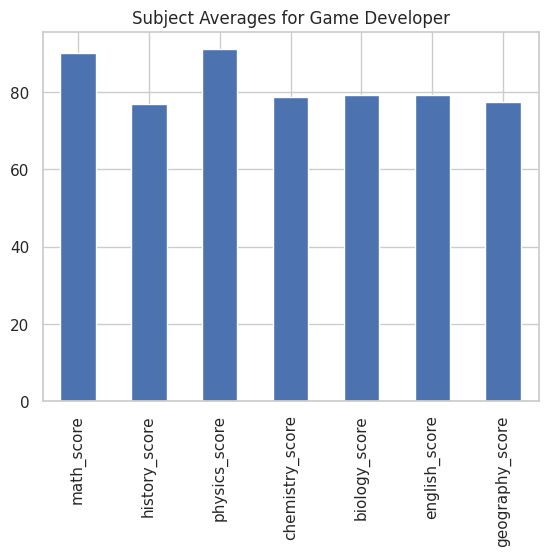

In [58]:
career_name = "Game Developer"
career_code = le_aspiration.transform([career_name])[0]
career_data = df[df['career_aspiration'] == career_code]
career_data[numeric_cols].mean().plot(kind='bar', title=f"Subject Averages for {career_name}")
plt.show()

# Define features (x) and target (y)

In [59]:
x = df.drop(["career_aspiration", "career_name"], axis=1)
y = df["career_aspiration"]

# Split Dataset into train/test sets

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train Model

In [61]:
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']  # Better feature sampling
}
grid = GridSearchCV(RandomForestClassifier(class_weight='balanced'),
                   params, cv=5, n_jobs=-1)
grid.fit(x_train, y_train)
best_model = grid.best_estimator_

In [62]:
print(f"Best Accuracy: {grid.best_score_:.3f}")

Best Accuracy: 0.925


In [63]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on the test set
y_pred = best_model.predict(x_test)

# Evaluate the model
print("Model Evaluation on Test Set:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_aspiration.classes_)) # Use loaded_label_encoder to get class names
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Evaluation on Test Set:
Accuracy: 0.989

Classification Report:
                       precision    recall  f1-score   support

           Accountant       1.00      1.00      1.00        74
               Artist       1.00      1.00      1.00        33
               Banker       0.97      1.00      0.99       102
       Business Owner       1.00      1.00      1.00       189
Construction Engineer       1.00      1.00      1.00        27
             Designer       0.91      0.91      0.91        35
               Doctor       0.97      1.00      0.98        89
       Game Developer       1.00      1.00      1.00        38
   Government Officer       1.00      0.86      0.93        44
               Lawyer       1.00      1.00      1.00        73
Real Estate Developer       1.00      0.94      0.97        48
            Scientist       1.00      1.00      1.00        33
    Software Engineer       0.98      1.00      0.99       188
       Stock Investor       1.00      1.00     

# Save Models & Label Encoders

In [64]:
# Save the best model
joblib.dump(best_model, 'best_academic_model.pkl')

['best_academic_model.pkl']

In [65]:
# Save the label encoder (critical for decoding predictions)
joblib.dump(le_aspiration, 'academic_label_encoder.pkl')

['academic_label_encoder.pkl']

In [66]:
# Save the complete GridSearchCV object
joblib.dump(grid, 'academic_grid_search_results.pkl')

['academic_grid_search_results.pkl']

In [67]:
# Load the saved model and label encoder
loaded_model = joblib.load('best_academic_model.pkl')
loaded_label_encoder = joblib.load('academic_label_encoder.pkl')

# Create a sample input (replace with your actual data)
# Make sure the order of columns matches the training data (x)
sample_input = pd.DataFrame({
    'gender': [0],  # 0 for male, 1 for female
    'extracurricular_activities': [1], # 1 for yes, 0 for no
    'math_score': [90],
    'history_score': [85],
    'physics_score': [95],
    'chemistry_score': [92],
    'biology_score': [88],
    'english_score': [80],
    'geography_score': [75]
})

# Make a prediction
predicted_label = loaded_model.predict(sample_input)

# Decode the predicted label back to the original career name
predicted_career = loaded_label_encoder.inverse_transform(predicted_label)

print(f"Predicted Career Aspiration: {predicted_career[0]}")

Predicted Career Aspiration: Doctor


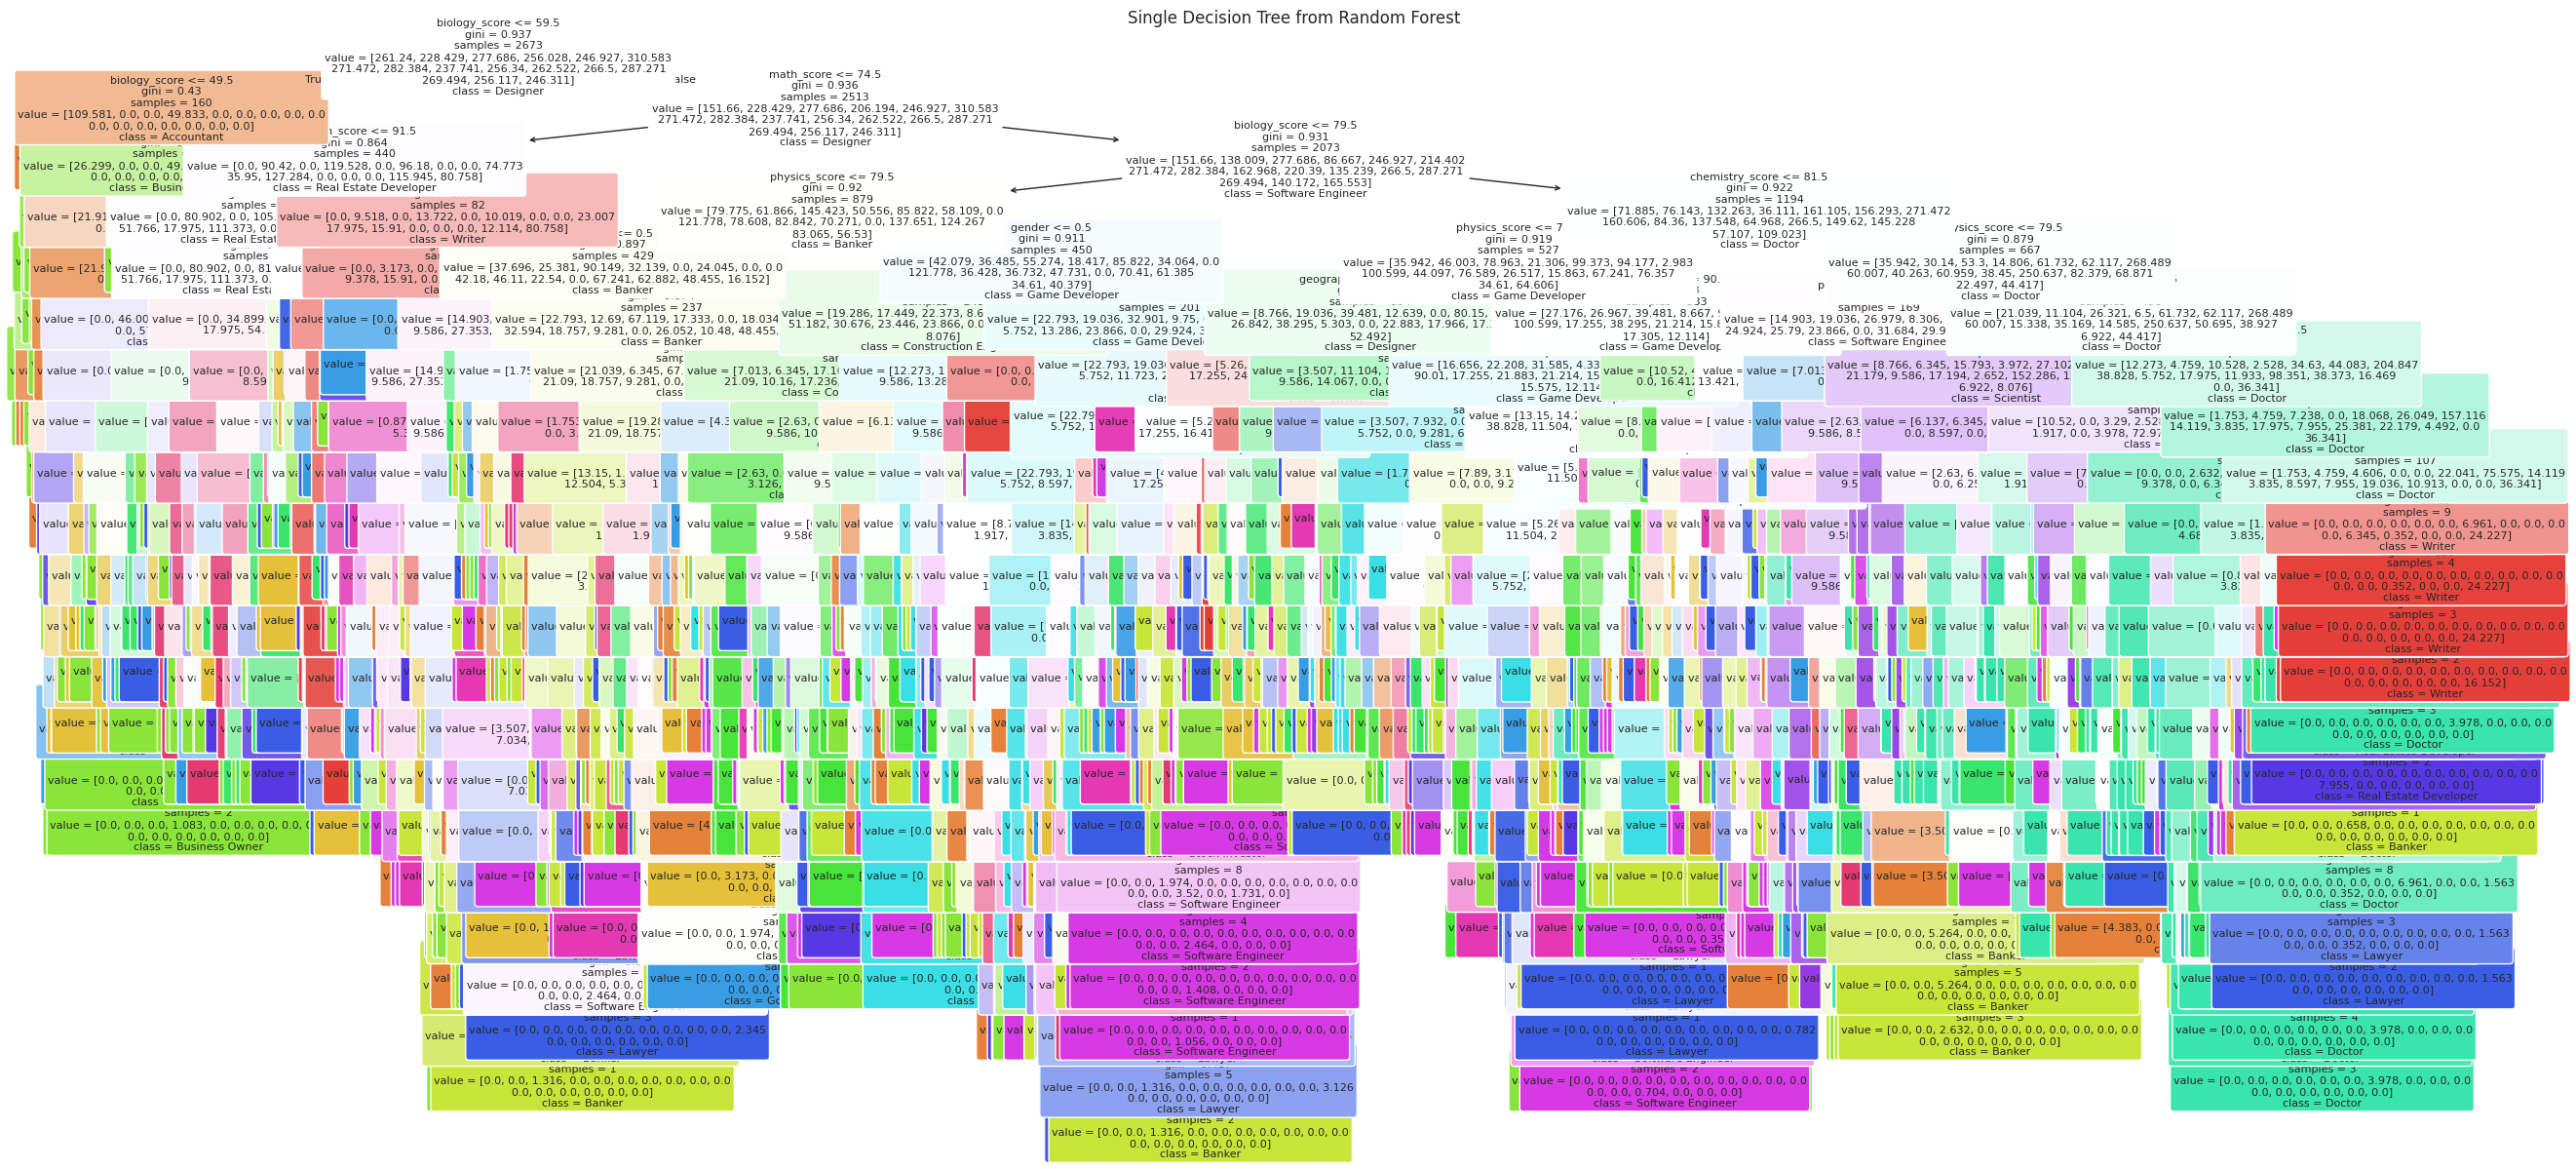

In [68]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Select a single tree from the Random Forest model (e.g., the first one)
single_tree = best_model.estimators_[0]

# Get feature names
feature_names = x_train.columns.tolist()

# Visualize the tree
plt.figure(figsize=(30, 15)) # Increased figure size
plot_tree(single_tree,
          feature_names=feature_names,
          class_names=loaded_label_encoder.classes_,
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Single Decision Tree from Random Forest")
plt.show()